# Test 6b — Why the CNN scores low on the public part, and an improved peak CNN

Test 6's `CNN_peaks` scored **0.710 private but only 0.594 public**, while B0 (the winner's method) scored 0.701 / 0.879. Its cross-validation (CV) was also below B0 (signal-level 0.684 vs 0.726; 160 vs 95 false alarms). And the Test 6 "blend" chose a CNN weight of **w = 0**, so it was simply B0 on a rescaled probability scale.

This notebook has two parts.

**Part A — Diagnosis (no new CNN training).** Uses the saved Test 5 and Test 6 predictions to find out *why* the CNN does worse on the hidden test:

| Check | Question it answers |
|---|---|
| A1. Submission files | Are the B0 and Test 6 blend files actually different? (Settles which file scored 0.672 public.) |
| A2. Flag rates | Does each model flag more or fewer measurements on the Kaggle test than in CV? |
| A3. Agreement | Where do the CNN and B0 disagree, and in CV, which of them is usually right? |
| A4. Properties | What do the measurements that only the CNN flags look like (noise floor, peak counts, interference)? |
| A5. Phase plot | Cleaned peaks across the voltage cycle: PD vs normal (pool) and the Kaggle test |
| A6. Position | Are the CNN-only flags clustered in particular ranges of the Kaggle test? |
| A7. Adversarial validation | Can a model tell training measurements from Kaggle-test ones, and using which inputs? |

**Part B — Test 6b models.** Three variants, each adding **one** change, on the **same 10 × 5 folds** as Tests 5 and 6:

| Variant | Change |
|---|---|
| `CNN6b_1_shared` | One encoder shared by all three phases; phases combined by mean and max pooling (built-in symmetry, like B0 pooling all three phases) |
| `CNN6b_2_side` | + B0's 9 measurement features as a side input |
| `CNN6b_3_aug` | + stronger augmentation (per-sample shifts, each phase shifted separately, height jitter, random empty bins) |

Every model, including B0 and `CNN_peaks`, is re-scored with **one cut-off rule** (ties → middle of the tied range). An extra column reports MCC on the **30% of CV measurements that look most like the Kaggle test** (from A7).

**Pre-registered submission rule (fixed before any result is seen):** submit at most two files: (1) the 6b variant with the best signal-level CV MCC; (2) its calibrated blend with B0, **only if 0 < w < 1** (if w is 0 or 1, the blend is just one of the models). Both scores (private and public) are reported, and models are judged on both parts together.

**Inputs to attach:** the committed outputs of **Data prep v4**, **Test 5** and **Test 6**. A GPU speeds up Part B but isn't required. Run once with `QUICK_TEST = True` to check everything loads, then set it to `False` and commit with **Save & Run All**.

## 1. Settings

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import glob, json, random, time, warnings
warnings.filterwarnings('ignore', message='.*eval_set.*')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import matthews_corrcoef, confusion_matrix, roc_auc_score

torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

QUICK_TEST = False          # True = 1 repeat and 5 epochs per model, only to check the notebook runs

N_REPEATS, N_FOLDS, SEED_BASE = (1 if QUICK_TEST else 10), 5, 1000   # same fold seeds as Tests 5 and 6
N_BINS = 64                                                         # 5.625 degrees per bin
BATCH_SIZE, MAX_EPOCHS, PATIENCE, LR, WEIGHT_DECAY = 64, (5 if QUICK_TEST else 150), 20, 1e-3, 1e-3
MAX_SHIFT = 2               # global shift of up to ±2 bins (as in Test 6)
PHASE_SHIFT = 1             # 6b-3: extra shift of up to ±1 bin for each phase separately
HEIGHT_JITTER = 0.25        # 6b-3: relative heights multiplied by exp(N(0, 0.25²)) per phase
BIN_DROP = 0.05             # 6b-3: share of bins emptied at random
TEST_LIKE_SHARE = 0.30      # share of CV measurements treated as 'most like the Kaggle test'
THRESHOLDS = np.r_[np.arange(0.01, 0.99, 0.01), np.arange(0.99, 0.9995, 0.001)].round(3)   # finer above 0.98: class-weighted CNNs can need high cut-offs
INPUT_DIR, OUT_DIR = '/kaggle/input', '/kaggle/working'

# Colours (kept the same in every figure)
C_B0, C_CNN, C_AQUA, C_GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#8a8985'
C_PD, C_NORMAL, C_KAGGLE = '#eb6834', '#8a8985', '#2a78d6'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device, '| PyTorch', torch.__version__, '| LightGBM', lgb.__version__,
      '| QUICK_TEST' if QUICK_TEST else '')

Using device: cuda | PyTorch 2.11.0+cu128 | LightGBM 4.6.0 


## 2. Load the inputs

Data prep v4 gives the peak table, per-signal statistics (noise floor, fallback use) and phase offsets (50 Hz amplitude). Test 5 and Test 6 give their saved predictions, cut-offs and submission files. The checks stop the notebook if an input is missing or comes from a quick test.

In [2]:
def find(name, required=True):
    m = sorted(glob.glob(f'{INPUT_DIR}/**/{name}', recursive=True))
    assert m or not required, f'{name} not found: attach the committed output that contains it'
    return m[0] if m else None

D = find('peaks_train.parquet').rsplit('/', 1)[0]
meta = pd.read_csv(f'{D}/meta_train.csv')
meta_k = pd.read_csv(f'{D}/meta_kaggle_test.csv')
assert len(meta) == 8712 and len(meta_k) == 20337, 'quick-test output attached: commit Data prep v4 with LIMIT = None'
assert 'split' in meta.columns, 'meta_train.csv has no split column: attach the Data prep v4 output'

t5 = np.load(find('test5_predictions.npz'))
t6 = np.load(find('test6_predictions.npz'))
set5 = json.load(open(find('test5_settings.json')))
set6 = json.load(open(find('test6_settings.json')))
print('Test 5 cut-offs:', set5['cutoffs'])
print('Test 6 cut-offs:', set6['cutoffs'], '| Test 6 blend weight w =', set6.get('blend_weight'))

Test 5 cut-offs: {'B0_winner': 0.39, 'B1_adapted': 0.34}
Test 6 cut-offs: {'CNN_peaks': 0.89, 'Blend_CNNpeaks_B0': 0.46} | Test 6 blend weight w = 0


## 3. Peak tables, grids and B0 features

The grids are built exactly as in Test 6 (3 phases × 10 channels × 64 bins, after the winner's interference filter). B0's 9 features are rebuilt with Test 5's code, for the 6b-2 side input and for adversarial validation. A table of **recording descriptors** per measurement is also built for the diagnosis: noise-floor height, local maxima found, peaks kept, fallback use, 50 Hz amplitude, and peaks removed by the interference filter.

In [3]:
COUNT_CH = ['count', 'count_pos', 'count_neg', 'sum_rel_height']
MEAN_CH = ['sawtooth_2', 'sawtooth_3', 'ratio_next', 'ratio_prev', 'abs_dist', 'width']
CHANNELS = COUNT_CH + MEAN_CH
N_CH = len(CHANNELS)

def load(name, m):
    p = pd.read_parquet(f'{D}/peaks_{name}.parquet')
    s = pd.read_csv(f'{D}/signals_{name}.csv')
    o = pd.read_csv(f'{D}/phase_offsets_{name}.csv')[['signal_id', 'amplitude']]
    s = s.merge(o, on='signal_id', how='left').merge(m[['signal_id', 'id_measurement', 'phase']], on='signal_id')
    p = p.merge(m[['signal_id', 'id_measurement', 'phase']], on='signal_id').merge(s[['signal_id', 'knee_height']], on='signal_id')
    interference = (p['ratio_next'] > 1 / 3) & (p['height'] > 50)                 # winner's interference filter
    removed = p[interference].groupby('id_measurement').size()
    p = p[~interference].copy()
    p['rel_height'] = p['height'] / p['knee_height'].clip(lower=1e-6)
    p['abs_dist'] = p['small_dist_to_min'].abs().astype(np.float32)
    p['bin'] = (p['phase_deg'] / (360 / N_BINS)).astype(int).clip(0, N_BINS - 1)
    return p, s, removed

peaks, sig, removed = load('train', meta)
peaks_k, sig_k, removed_k = load('kaggle_test', meta_k)
FILL = peaks[MEAN_CH].astype(float).mean()

def build_grid(p, m):                                    # identical to Test 6
    ids = np.sort(m['id_measurement'].unique())
    row = pd.Series(np.arange(len(ids)), index=ids)
    r, ph, b = row.loc[p['id_measurement']].values, p['phase'].values, p['bin'].values
    G = np.zeros((len(ids), 3, N_CH, N_BINS), dtype=np.float32)
    np.add.at(G, (r, ph, 0, b), np.ones(len(p), dtype=np.float32))
    np.add.at(G, (r, ph, 1, b), (p['sign'].values > 0).astype(np.float32))
    np.add.at(G, (r, ph, 2, b), (p['sign'].values < 0).astype(np.float32))
    np.add.at(G, (r, ph, 3, b), p['rel_height'].values.astype(np.float32))
    counts = G[:, :, 0, :].copy()
    for j, c in enumerate(MEAN_CH, start=len(COUNT_CH)):
        np.add.at(G, (r, ph, j, b), p[c].values.astype(np.float32))
        G[:, :, j, :] = np.where(counts > 0, G[:, :, j, :] / np.maximum(counts, 1), FILL[c])
    G[:, :, :len(COUNT_CH), :] = np.log1p(G[:, :, :len(COUNT_CH), :])
    return ids, G.reshape(len(ids), 3 * N_CH, N_BINS)

B0_COLS = ['peak_count_Q13', 'abs_small_dist_to_min_mean_Q02', 'height_mean_Q02', 'height_std_Q02',
           'sawtooth_rmse_mean_Q02', 'peak_count_Q02', 'ratio_next_mean_Q02', 'ratio_prev_mean_Q02', 'peak_count_total']

def b0_features(p, ids):                                 # B0 part of Test 5's build_features (peaks already filtered)
    p = p.assign(Q=(p['phase_deg'] // 90).astype(int).clip(0, 3))
    f = pd.DataFrame(index=pd.Index(ids, name='id_measurement'))
    g = p[p['Q'].isin([0, 2])].groupby('id_measurement')
    f['peak_count_Q02'] = g.size()
    f['peak_count_Q13'] = p[p['Q'].isin([1, 3])].groupby('id_measurement').size()
    f['peak_count_total'] = p.groupby('id_measurement').size()
    f['height_mean_Q02'] = g['height'].mean()
    f['height_std_Q02'] = g['height'].std()
    f['ratio_prev_mean_Q02'] = g['ratio_prev'].mean()
    f['ratio_next_mean_Q02'] = g['ratio_next'].mean()
    f['abs_small_dist_to_min_mean_Q02'] = g['abs_dist'].mean()
    f['sawtooth_rmse_mean_Q02'] = g['sawtooth_3'].mean()
    return f[B0_COLS]

def descriptors(s, removed_n, ids):
    g = s.groupby('id_measurement')
    d = pd.DataFrame(index=pd.Index(ids, name='id_measurement'))
    d['noise_floor_mean'] = np.log(g['knee_height'].mean().clip(lower=1e-6))
    d['noise_floor_max'] = np.log(g['knee_height'].max().clip(lower=1e-6))
    d['local_maxima_mean'] = g['n_local_maxima'].mean()
    d['peaks_kept_mean'] = g['n_peaks'].mean()
    d['fallback_phases'] = g['fallback'].sum()
    d['amp50_mean'] = g['amplitude'].mean()
    d['amp50_min'] = g['amplitude'].min()
    d['interference_removed'] = removed_n.reindex(ids).fillna(0).values
    return d

ids_all, G = build_grid(peaks, meta)
ids_k, G_k = build_grid(peaks_k, meta_k)
F_b0, F_b0_k = b0_features(peaks, ids_all), b0_features(peaks_k, ids_k)
DESC, DESC_k = descriptors(sig, removed, ids_all), descriptors(sig_k, removed_k, ids_k)

y_meas = meta.groupby('id_measurement')['target'].max().loc[ids_all].values
split = meta.groupby('id_measurement')['split'].first().loc[ids_all].values
pool = np.where(np.isin(split, ['train', 'val']))[0]
test_rows = np.where(split == 'test')[0]
pool_ids, yp = ids_all[pool], y_meas[pool]
pool_sig = meta[meta['id_measurement'].isin(pool_ids)]
print('Grid:', G.shape, '| Kaggle:', G_k.shape, f'| pool: {len(pool)} measurements ({yp.sum()} PD), {len(pool_sig)} signals')

Grid: (2904, 30, 64) | Kaggle: (6779, 30, 64) | pool: 2468 measurements (165 PD), 7404 signals


## 4. Shared scoring functions (one cut-off rule for every model)

Signal-level scoring gives each measurement's prediction to its three signals. The cut-off is chosen on CV predictions from 0.01 to 0.999 (steps of 0.01, then 0.001 above 0.98, because class-weighted CNNs can need very high cut-offs: `CNN_peaks` already needed 0.89). **If several cut-offs tie, the middle one is taken** (Test 6's rule; Test 5 took the lowest). B0 and `CNN_peaks` are re-scored with this rule, so every row of the final table is like-for-like.

In [4]:
def to_signal(p, ids, m):
    return m['id_measurement'].map(pd.Series(p, index=ids)).values

def best_signal_cut(p, ids=None, m=None):
    ids = pool_ids if ids is None else ids; m = pool_sig if m is None else m
    ps, ys = to_signal(p, ids, m), m['target'].values
    scores = np.array([matthews_corrcoef(ys, ps > t) for t in THRESHOLDS])
    tied = np.flatnonzero(scores == scores.max())
    i = int(tied[len(tied) // 2]); return float(scores[i]), float(THRESHOLDS[i])

def signal_mcc_at(p, cut, ids, m):
    return matthews_corrcoef(m['target'].values, to_signal(p, ids, m) > cut)

def meas_mcc(p, y=None):
    y = yp if y is None else y
    return max(matthews_corrcoef(y, p > t) for t in THRESHOLDS)

def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))

def calibrator(p, y):
    lr = LogisticRegression(C=1e6).fit(logit(p)[:, None], y)
    return lambda q: lr.predict_proba(logit(q)[:, None])[:, 1]

def align(values, saved_ids, ids):
    return pd.Series(values, index=saved_ids).loc[ids].values

# Saved CV (pool) and Kaggle predictions of the earlier models, in this notebook's order
SAVED = {'B0_winner': (align(t5['oof_B0_winner'], t5['pool_ids'], pool_ids), align(t5['kaggle_B0_winner'], t5['kaggle_ids'], ids_k)),
         'B1_adapted': (align(t5['oof_B1_adapted'], t5['pool_ids'], pool_ids), align(t5['kaggle_B1_adapted'], t5['kaggle_ids'], ids_k)),
         'CNN_peaks': (align(t6['oof_CNN_peaks'], t6['pool_ids'], pool_ids), align(t6['kaggle_CNN_peaks'], t6['kaggle_ids'], ids_k))}
SUBMITTED_CUT = {'B0_winner': set5['cutoffs']['B0_winner'], 'B1_adapted': set5['cutoffs']['B1_adapted'],
                 'CNN_peaks': set6['cutoffs']['CNN_peaks']}
for name, (o, _) in SAVED.items():
    s, c = best_signal_cut(o)
    print(f'{name:11s} signal-level CV MCC {s:.3f} | cut-off {c:.2f} with the middle-tie rule (submitted: {SUBMITTED_CUT[name]:.2f})')

B0_winner   signal-level CV MCC 0.726 | cut-off 0.39 with the middle-tie rule (submitted: 0.39)
B1_adapted  signal-level CV MCC 0.753 | cut-off 0.34 with the middle-tie rule (submitted: 0.34)
CNN_peaks   signal-level CV MCC 0.684 | cut-off 0.89 with the middle-tie rule (submitted: 0.89)


# Part A — Diagnosis

## A1. Are the B0 and Test 6 blend submission files different?

With w = 0 the Test 6 blend is B0 on a rescaled scale, so the two files can only differ through the cut-off. If they are **identical**, they must have received identical scores on both parts, and the 0.672 public score recorded for the blend belongs to a different submission.

In [5]:
files = {'B0_winner': find('submission_B0_winner.csv', False), 'Blend_CNNpeaks_B0': find('submission_Blend_CNNpeaks_B0.csv', False),
         'CNN_peaks': find('submission_CNN_peaks.csv', False), 'B1_adapted': find('submission_B1_adapted.csv', False)}
subs = {k: pd.read_csv(v).set_index('signal_id')['target'] for k, v in files.items() if v}
for k, s in subs.items():
    print(f'{k:18s}: {s.sum():4d} signals predicted PD ({s.mean():.1%}) in {meta_k.loc[meta_k["signal_id"].isin(s.index[s == 1]), "id_measurement"].nunique()} measurements')
if 'B0_winner' in subs and 'Blend_CNNpeaks_B0' in subs:
    a, b = subs['B0_winner'], subs['Blend_CNNpeaks_B0'].loc[subs['B0_winner'].index]
    n_diff = int((a != b).sum())
    if n_diff == 0:
        print('\nB0 and blend files are IDENTICAL: they must have identical private AND public scores. '
              'Check My Submissions: the 0.672 public score belongs to a different file.')
    else:
        only_b0, only_blend = int(((a == 1) & (b == 0)).sum()), int(((a == 0) & (b == 1)).sum())
        print(f'\nB0 and blend files differ in {n_diff} signals ({only_b0} flagged only by B0, {only_blend} only by the blend).')
else:
    print('Submission files not found: attach the Test 5 and Test 6 outputs to run this check.')

B0_winner         :  741 signals predicted PD (3.6%) in 247 measurements
Blend_CNNpeaks_B0 :  744 signals predicted PD (3.7%) in 248 measurements
CNN_peaks         :  867 signals predicted PD (4.3%) in 289 measurements
B1_adapted        :  807 signals predicted PD (4.0%) in 269 measurements

B0 and blend files differ in 3 signals (0 flagged only by B0, 3 only by the blend).


## A2. Flag rates in CV vs on the Kaggle test

For each submitted model (at its **submitted** cut-off): the share of measurements flagged as PD in CV (pool) and on the Kaggle test. The pool contains about 6–7% PD measurements; earlier tests suggested the Kaggle test contains fewer. A model whose Kaggle flag rate is high relative to its pool rate is flagging extra measurements on the Kaggle test, most likely as false alarms.

The histograms show each model's predictions on the log-odds scale for the pool and the Kaggle test, with the cut-off marked. A shift between the two distributions near the cut-off changes how many measurements are flagged.

,Model,Submitted cut-off,Pool flag rate,Pool PD rate,Kaggle flag rate,Kaggle / pool,Kaggle flagged measurements
0,B0_winner,0.39,5.63%,6.69%,3.64%,0.65,247
1,B1_adapted,0.34,5.79%,6.69%,3.97%,0.68,269
2,CNN_peaks,0.89,6.65%,6.69%,4.26%,0.64,289


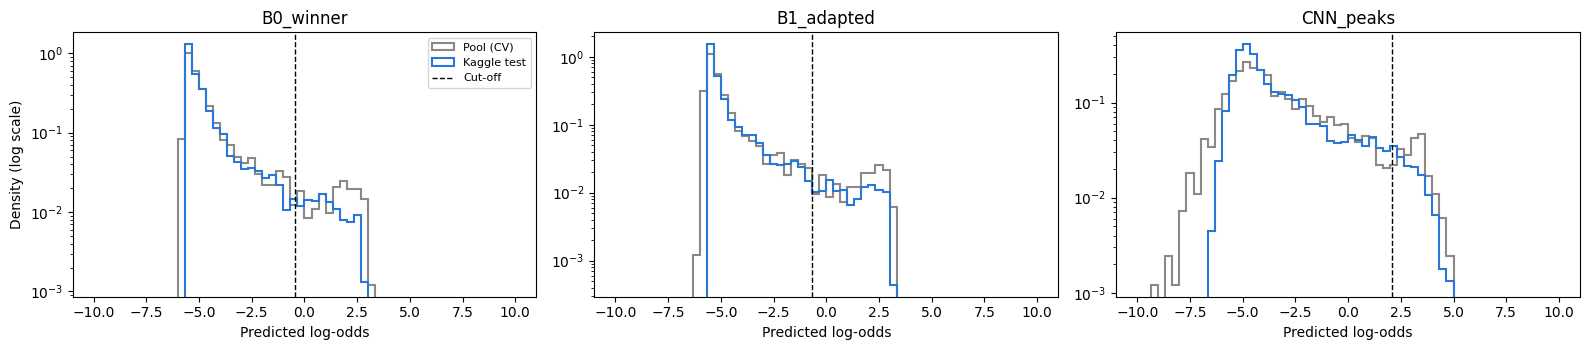

In [6]:
rows = []
for name, (o, k) in SAVED.items():
    c = SUBMITTED_CUT[name]
    rows.append({'Model': name, 'Submitted cut-off': c, 'Pool flag rate': f'{(o > c).mean():.2%}',
                 'Pool PD rate': f'{yp.mean():.2%}', 'Kaggle flag rate': f'{(k > c).mean():.2%}',
                 'Kaggle / pool': round((k > c).mean() / max((o > c).mean(), 1e-9), 2),
                 'Kaggle flagged measurements': int((k > c).sum())})
flag_rates = pd.DataFrame(rows); display(flag_rates)

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
for ax, (name, (o, k)) in zip(axes, SAVED.items()):
    bins = np.linspace(-10, 10, 61)
    ax.hist(np.clip(logit(o), -10, 10), bins=bins, density=True, histtype='step', linewidth=1.5, color=C_GRAY, label='Pool (CV)')
    ax.hist(np.clip(logit(k), -10, 10), bins=bins, density=True, histtype='step', linewidth=1.5, color=C_KAGGLE, label='Kaggle test')
    ax.axvline(logit(np.array([SUBMITTED_CUT[name]]))[0], color='black', linestyle='--', linewidth=1, label='Cut-off')
    ax.set_yscale('log'); ax.set_title(name); ax.set_xlabel('Predicted log-odds')
axes[0].set_ylabel('Density (log scale)'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## A3. Where the CNN and B0 agree and disagree

Each measurement is placed in one of four groups by the two submitted models' decisions. **In CV (pool), the labels are known**, so the PD share in each group shows which model is usually right when they disagree. On the Kaggle test, only the group sizes are known.

In [7]:
def groups(cnn_flag, b0_flag):
    return np.select([cnn_flag & b0_flag, cnn_flag & ~b0_flag, ~cnn_flag & b0_flag], ['both', 'only CNN', 'only B0'], 'neither')

(o_b0, k_b0), (o_cnn, k_cnn) = SAVED['B0_winner'], SAVED['CNN_peaks']
grp_pool = groups(o_cnn > SUBMITTED_CUT['CNN_peaks'], o_b0 > SUBMITTED_CUT['B0_winner'])
grp_k = groups(k_cnn > SUBMITTED_CUT['CNN_peaks'], k_b0 > SUBMITTED_CUT['B0_winner'])
order = ['both', 'only CNN', 'only B0', 'neither']
agree = pd.DataFrame({
    'Pool measurements': pd.Series(grp_pool).value_counts().reindex(order, fill_value=0),
    'Pool PD share': pd.Series(yp).groupby(grp_pool).mean().reindex(order).map(lambda v: f'{v:.1%}' if pd.notna(v) else '—'),
    'Kaggle measurements': pd.Series(grp_k).value_counts().reindex(order, fill_value=0)})
agree['Kaggle / pool size'] = (agree['Kaggle measurements'] / agree['Pool measurements'].clip(lower=1)).round(2)
display(agree)
print(f'Kaggle test has {len(ids_k) / len(pool):.2f}× as many measurements as the pool: '
      'a group whose ratio is well above this has grown on the Kaggle test.')

,Pool measurements,Pool PD share,Kaggle measurements,Kaggle / pool size
both,126,87.3%,222,1.76
only CNN,38,23.7%,67,1.76
only B0,13,46.2%,25,1.92
neither,2291,1.7%,6465,2.82


Kaggle test has 2.75× as many measurements as the pool: a group whose ratio is well above this has grown on the Kaggle test.


## A4. What the disagreement measurements look like (Kaggle test)

Median recording descriptors per group. For reference, the last two columns give the same medians for pool normal and pool PD measurements. If the 'only CNN' group looks like noisy or interference-heavy normal recordings (high noise floor, many removed interference peaks, many local maxima), the CNN's extra flags on the Kaggle test are most likely false alarms.

In [8]:
desc_k = DESC_k.assign(peaks_total=F_b0_k['peak_count_total'].fillna(0).values, peaks_Q02=F_b0_k['peak_count_Q02'].fillna(0).values)
desc_p = DESC.loc[pool_ids].assign(peaks_total=F_b0.loc[pool_ids, 'peak_count_total'].fillna(0).values,
                                   peaks_Q02=F_b0.loc[pool_ids, 'peak_count_Q02'].fillna(0).values)
props = desc_k.groupby(grp_k).median().reindex(order).T
props['pool normal'] = desc_p[yp == 0].median()
props['pool PD'] = desc_p[yp == 1].median()
props = props.round(2).astype(object)
props.loc['measurements'] = [int((grp_k == g).sum()) for g in order] + [int((yp == 0).sum()), int(yp.sum())]
display(props)

,both,only CNN,only B0,neither,pool normal,pool PD
noise_floor_mean,1.65,1.51,1.81,1.7,1.67,1.76
noise_floor_max,1.72,1.57,1.91,1.8,1.77,1.83
local_maxima_mean,13592.5,13370.33,14052.0,13389.0,13427.67,13849.67
peaks_kept_mean,291.0,210.67,264.33,60.0,81.67,300.67
fallback_phases,0.0,0.0,0.0,0.0,0.0,0.0
amp50_mean,19.4,19.12,20.75,20.67,20.54,19.52
amp50_min,18.76,18.42,20.29,19.99,19.79,18.76
interference_removed,0.0,0.0,11.0,0.0,0.0,3.0
peaks_total,871.0,632.0,770.0,178.0,242.0,899.0
peaks_Q02,394.5,279.0,422.0,91.0,105.0,399.0


## A5. Cleaned peaks across the voltage cycle

Average number of cleaned peaks per bin (all three phases combined) for pool PD and pool normal measurements, the whole Kaggle test, and the Kaggle measurements flagged only by the CNN. This also gives the phase-resolved figure missing from the Test 6 report.

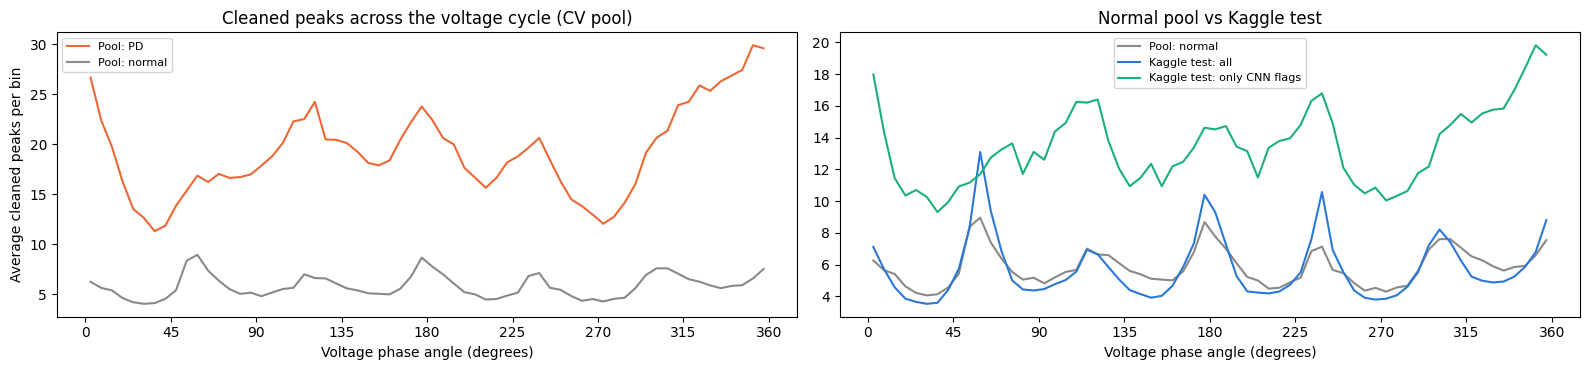

In [9]:
def avg_counts(Gx):
    return np.expm1(Gx.reshape(len(Gx), 3, N_CH, N_BINS)[:, :, 0, :]).sum(axis=1).mean(axis=0)

angles = (np.arange(N_BINS) + 0.5) * 360 / N_BINS
fig, axes = plt.subplots(1, 2, figsize=(16, 3.8), sharex=True)
axes[0].plot(angles, avg_counts(G[pool][yp == 1]), color=C_PD, linewidth=1.5, label='Pool: PD')
axes[0].plot(angles, avg_counts(G[pool][yp == 0]), color=C_NORMAL, linewidth=1.5, label='Pool: normal')
axes[0].set_title('Cleaned peaks across the voltage cycle (CV pool)')
axes[1].plot(angles, avg_counts(G[pool][yp == 0]), color=C_NORMAL, linewidth=1.5, label='Pool: normal')
axes[1].plot(angles, avg_counts(G_k), color=C_KAGGLE, linewidth=1.5, label='Kaggle test: all')
if (grp_k == 'only CNN').any():
    axes[1].plot(angles, avg_counts(G_k[grp_k == 'only CNN']), color=C_AQUA, linewidth=1.5, label='Kaggle test: only CNN flags')
axes[1].set_title('Normal pool vs Kaggle test')
for ax in axes:
    ax.set_xticks(range(0, 361, 45)); ax.set_xlabel('Voltage phase angle (degrees)'); ax.legend(fontsize=8)
axes[0].set_ylabel('Average cleaned peaks per bin')
plt.tight_layout(); plt.show()

## A6. Where the flags fall within the Kaggle test

Flag rate along the Kaggle test in measurement-ID order (rolling average over 200 measurements). If the CNN-only flags pile up in particular ID ranges, they come from particular groups of recordings rather than being spread evenly. (Whether ID order follows recording time isn't documented, so this shows clustering, not dates.)

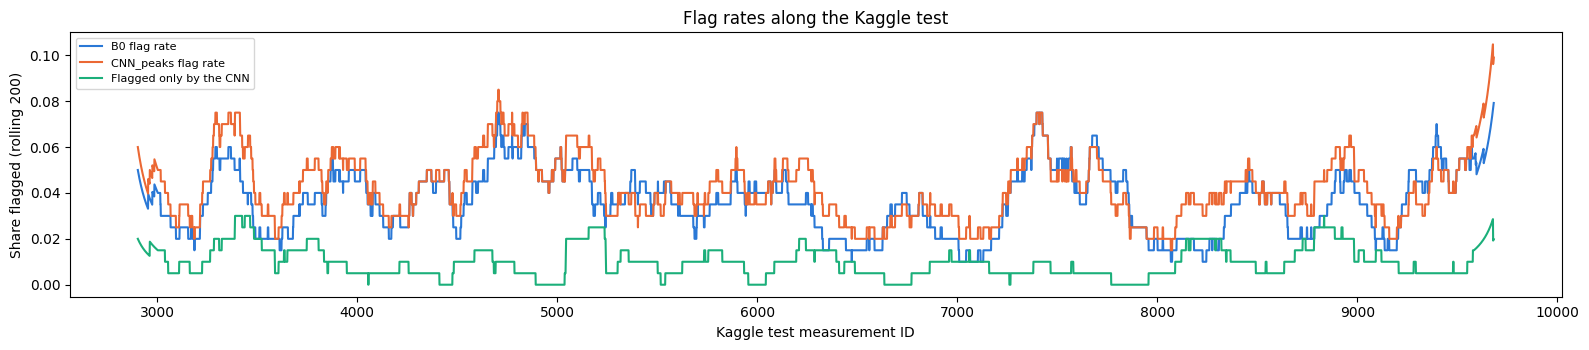

In [10]:
W = 200
roll = lambda v: pd.Series(v.astype(float)).rolling(W, center=True, min_periods=W // 4).mean()
fig, ax = plt.subplots(figsize=(16, 3.6))
ax.plot(ids_k, roll(k_b0 > SUBMITTED_CUT['B0_winner']), color=C_B0, linewidth=1.5, label='B0 flag rate')
ax.plot(ids_k, roll(k_cnn > SUBMITTED_CUT['CNN_peaks']), color=C_CNN, linewidth=1.5, label='CNN_peaks flag rate')
ax.plot(ids_k, roll(grp_k == 'only CNN'), color=C_AQUA, linewidth=1.5, label='Flagged only by the CNN')
ax.set_xlabel('Kaggle test measurement ID'); ax.set_ylabel(f'Share flagged (rolling {W})')
ax.set_title('Flag rates along the Kaggle test'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## A7. Adversarial validation

A LightGBM model is trained to tell **labelled measurements (label 0)** from **Kaggle-test measurements (label 1)**, with 5-fold cross-validation. The out-of-fold AUC measures how different the two sets are: **0.5 = indistinguishable**, above about 0.7 = clearly different. It is run separately on three groups of inputs, then on all of them together:

| Group | Inputs |
|---|---|
| B0 features | The 9 measurement features of the winner's method |
| Grid summaries | For each of the 10 CNN channels: mean over bins and phases, and the bin maximum (averaged over phases) |
| Recording descriptors | Noise floor, local maxima, peaks kept, fallback use, 50 Hz amplitude, interference peaks removed |

Each labelled measurement's out-of-fold score from the combined model is its **test-likeness**. The 30% of pool measurements with the highest test-likeness form the **test-like subset** used in Part B.

,Inputs,Adversarial AUC
0,B0 features,0.748
1,Grid summaries,0.769
2,Recording descriptors,0.880
3,All combined,0.914


Test-like subset: 741 pool measurements (48 PD), 2223 signals


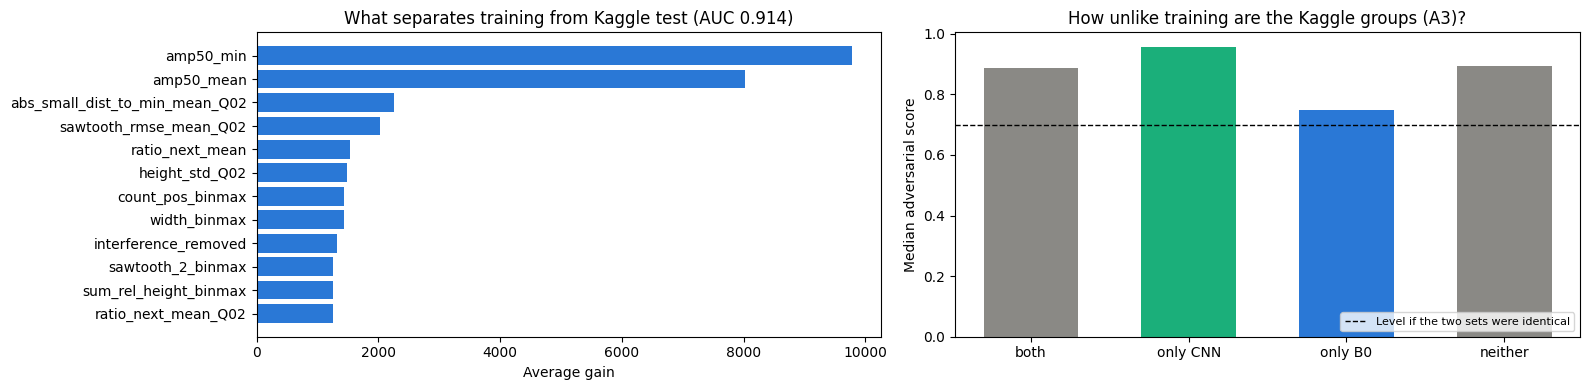

In [11]:
def grid_summary(Gx):
    g = Gx.reshape(len(Gx), 3, N_CH, N_BINS)
    return pd.DataFrame(np.concatenate([g.mean(axis=(1, 3)), g.max(axis=3).mean(axis=1)], axis=1),
                        columns=[f'{c}_mean' for c in CHANNELS] + [f'{c}_binmax' for c in CHANNELS])

AV_GROUPS = {'B0 features': (F_b0.reset_index(drop=True), F_b0_k.reset_index(drop=True)),
             'Grid summaries': (grid_summary(G), grid_summary(G_k)),
             'Recording descriptors': (DESC.reset_index(drop=True), DESC_k.reset_index(drop=True))}
AV_GROUPS['All combined'] = (pd.concat([v[0] for v in AV_GROUPS.values()], axis=1),
                             pd.concat([v[1] for v in AV_GROUPS.values()], axis=1))
AV_PARAMS = dict(objective='binary', learning_rate=0.05, num_leaves=15, n_estimators=300, colsample_bytree=0.8,
                 subsample=0.8, subsample_freq=1, verbose=-1)

def adversarial(Xl, Xk):
    X = pd.concat([Xl, Xk], ignore_index=True); yv = np.r_[np.zeros(len(Xl)), np.ones(len(Xk))]
    oof_av, imp = np.zeros(len(X)), np.zeros(X.shape[1])
    for k, (tr, va) in enumerate(StratifiedKFold(5, shuffle=True, random_state=SEED_BASE).split(X, yv)):
        m = lgb.LGBMClassifier(**AV_PARAMS, random_state=SEED_BASE + k).fit(X.iloc[tr], yv[tr])
        oof_av[va] = m.predict_proba(X.iloc[va])[:, 1]; imp += m.booster_.feature_importance('gain') / 5
    return roc_auc_score(yv, oof_av), oof_av, pd.Series(imp, index=X.columns).sort_values(ascending=False)

av = {name: adversarial(*v) for name, v in AV_GROUPS.items()}
display(pd.DataFrame({'Inputs': list(av), 'Adversarial AUC': [round(v[0], 3) for v in av.values()]}))

auc_all, score_all, imp_all = av['All combined']
test_like = pd.Series(score_all[:len(ids_all)], index=ids_all)                     # labelled measurements
test_like_k = score_all[len(ids_all):]                                              # Kaggle measurements
cut_tl = test_like.loc[pool_ids].quantile(1 - TEST_LIKE_SHARE)
TL = test_like.loc[pool_ids].values >= cut_tl                                       # test-like subset of the pool
tl_ids = pool_ids[TL]; tl_sig = pool_sig[pool_sig['id_measurement'].isin(tl_ids)]
print(f'Test-like subset: {TL.sum()} pool measurements ({yp[TL].sum()} PD), {len(tl_sig)} signals')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
top = imp_all.head(12)
axes[0].barh(top.index[::-1], top.values[::-1], color=C_KAGGLE)
axes[0].set_xlabel('Average gain'); axes[0].set_title(f'What separates training from Kaggle test (AUC {auc_all:.3f})')
tl_by_group = pd.Series(test_like_k).groupby(grp_k).median().reindex(order)
axes[1].bar(order, tl_by_group.values, color=[C_GRAY, C_AQUA, C_B0, C_GRAY], width=0.6)
no_diff = len(ids_k) / (len(ids_k) + len(ids_all))
axes[1].axhline(no_diff, color='black', linestyle='--', linewidth=1, label='Level if the two sets were identical')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_ylabel('Median adversarial score'); axes[1].set_title('How unlike training are the Kaggle groups (A3)?')
plt.tight_layout(); plt.show()

# Part B — Test 6b models

## B1. The models and augmentation

**`SharedPhaseCNN`.** The same three circular convolution blocks as Test 6's `PeakCNN` (64 → 32 → 16 bins), but **one encoder is applied to each phase separately with shared weights** (10 channels in). Because each phase's bins are measured from its own zero crossing, bin *b* means the same point of the voltage cycle in all three phases. The three encoded phases are then combined by taking their **mean and maximum** at each bin, which makes the model treat the three phases symmetrically, as B0 does when it pools all three phases' peaks. A 1×1 convolution (128 → 32) and the same classifier as Test 6 follow; flattening keeps the information about *where* in the cycle patterns occur.

**Side input (6b-2, 6b-3).** B0's 9 features (counts and heights log-scaled, plus a 'no Q0/Q2 peaks' indicator; missing values filled with the training-part mean; standardised per fold) pass through a small layer (10 → 16) and are joined to the flattened CNN features before the classifier.

**Augmentation.** 6b-1 and 6b-2 use Test 6's shift (all bins by the same ±2, once per batch). 6b-3 uses, per measurement: a shift of ±2 bins, an extra ±1 bin for each phase separately, relative heights scaled by a random factor per phase, and 5% of bins emptied at random (counts set to zero, shape channels to the average). Augmentation is applied before normalisation.

In [12]:
def conv_block(ci, co, k, pool):
    layers = [nn.Conv1d(ci, co, k, padding=k // 2, padding_mode='circular'), nn.BatchNorm1d(co), nn.ReLU()]
    return nn.Sequential(*layers, nn.MaxPool1d(2)) if pool else nn.Sequential(*layers)

class SharedPhaseCNN(nn.Module):
    def __init__(self, n_side=0):
        super().__init__()
        self.encoder = nn.Sequential(conv_block(N_CH, 32, 5, False), conv_block(32, 32, 5, True), conv_block(32, 64, 3, True))
        self.mix = nn.Sequential(nn.Conv1d(128, 32, 1), nn.BatchNorm1d(32), nn.ReLU())
        self.flat = nn.Sequential(nn.Flatten(), nn.Dropout(0.5))
        self.side = nn.Sequential(nn.Linear(n_side, 16), nn.ReLU()) if n_side else None
        self.head = nn.Sequential(nn.Linear(32 * (N_BINS // 4) + (16 if n_side else 0), 32), nn.ReLU(),
                                  nn.Dropout(0.5), nn.Linear(32, 1))
    def forward(self, x, side=None):
        b = len(x)
        h = self.encoder(x.reshape(b * 3, N_CH, N_BINS)).reshape(b, 3, 64, N_BINS // 4)
        h = self.flat(self.mix(torch.cat([h.mean(dim=1), h.amax(dim=1)], dim=1)))
        if self.side is not None:
            h = torch.cat([h, self.side(side)], dim=1)
        return self.head(h).squeeze(1)

# Side input: B0's 9 features, transformed for a neural network
SIDE = F_b0.copy(); SIDE_K = F_b0_k.copy()
for S, F in ((SIDE, F_b0), (SIDE_K, F_b0_k)):
    for c in ['peak_count_Q02', 'peak_count_Q13', 'peak_count_total']:
        S[c] = np.log1p(F[c].fillna(0))
    for c in ['height_mean_Q02', 'height_std_Q02']:
        S[c] = np.log1p(F[c])
    S['no_Q02_peaks'] = (F['peak_count_Q02'].fillna(0) == 0).astype(float)
SIDE, SIDE_K = SIDE.values.astype(np.float64), SIDE_K.values.astype(np.float64)
N_SIDE = SIDE.shape[1]

EMPTY_BIN = torch.tensor([0.0] * len(COUNT_CH) + [float(FILL[c]) for c in MEAN_CH], device=device).view(1, 1, N_CH, 1)

def aug_shift(xb, gen):                                   # Test 6: one shift of all bins per batch
    s = int(torch.randint(-MAX_SHIFT, MAX_SHIFT + 1, (1,), generator=gen))
    return torch.roll(xb, shifts=s, dims=2)

def aug_strong(xb, gen):                                  # 6b-3
    b = len(xb); x = xb.reshape(b, 3, N_CH, N_BINS)
    shift = (torch.randint(-MAX_SHIFT, MAX_SHIFT + 1, (b, 1), generator=gen)
             + torch.randint(-PHASE_SHIFT, PHASE_SHIFT + 1, (b, 3), generator=gen)).to(x.device)
    idx = (torch.arange(N_BINS, device=x.device).view(1, 1, N_BINS) - shift.unsqueeze(2)) % N_BINS
    x = torch.gather(x, 3, idx.unsqueeze(2).expand(b, 3, N_CH, N_BINS))
    g = torch.exp(HEIGHT_JITTER * torch.randn(b, 3, generator=gen)).to(x.device)
    h = torch.log1p(torch.expm1(x[:, :, 3, :]) * g.unsqueeze(2))
    x = torch.cat([x[:, :, :3, :], h.unsqueeze(2), x[:, :, 4:, :]], dim=2)
    drop = (torch.rand(b, 3, 1, N_BINS, generator=gen) < BIN_DROP).to(x.device)
    x = torch.where(drop, EMPTY_BIN.expand(b, 3, N_CH, N_BINS), x)
    return x.reshape(b, 3 * N_CH, N_BINS)

VARIANTS = {'CNN6b_1_shared': dict(side=False, augment=aug_shift),
            'CNN6b_2_side': dict(side=True, augment=aug_shift),
            'CNN6b_3_aug': dict(side=True, augment=aug_strong)}
for v, cfg in VARIANTS.items():
    print(f'{v}: {sum(p.numel() for p in SharedPhaseCNN(N_SIDE if cfg["side"] else 0).parameters()):,} parameters')

CNN6b_1_shared: 33,889 parameters
CNN6b_2_side: 34,577 parameters
CNN6b_3_aug: 34,577 parameters


## B2. Training function

Identical to Test 6 apart from the model, the side input and the augmentation: per-fold channel normalisation from the training part, class-weighted loss, Adam with weight decay, early stopping on the **separate stopping fold's loss** (patience 20). Returns predictions for the CV fold, the internal test measurements and the Kaggle test.

In [13]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def side_scaler(tr):
    mu = np.nanmean(SIDE[tr], axis=0)
    fill = lambda a: np.where(np.isnan(a), mu, a)
    sd = fill(SIDE[tr]).std(axis=0) + 1e-6
    return lambda a: ((fill(a) - mu) / sd).astype(np.float32)

def predict(model, X, S=None):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), 512):
            xb = torch.tensor(X[i:i + 512], device=device)
            sb = None if S is None else torch.tensor(S[i:i + 512], device=device)
            out.append(torch.sigmoid(model(xb, sb)).cpu().numpy())
    return np.concatenate(out)

def train_fold(variant, tr, st, va, seed):
    cfg = VARIANTS[variant]
    mean = G[tr].mean(axis=(0, 2), keepdims=True); std = G[tr].std(axis=(0, 2), keepdims=True) + 1e-6
    norm = lambda a: ((a - mean) / std).astype(np.float32)
    mean_t, std_t = torch.tensor(mean, device=device), torch.tensor(std, device=device)
    sc = side_scaler(tr) if cfg['side'] else None
    side = (lambda rows: sc(SIDE[rows])) if sc else (lambda rows: None)
    Xtr = torch.tensor(G[tr], device=device)                                  # raw: augmented, then normalised per batch
    Xst = torch.tensor(norm(G[st]), device=device)
    Str = torch.tensor(side(tr), device=device) if sc else None
    Sst = torch.tensor(side(st), device=device) if sc else None
    ytr = torch.tensor(y_meas[tr], dtype=torch.float32, device=device)
    yst = torch.tensor(y_meas[st], dtype=torch.float32, device=device)
    set_seed(seed); gen = torch.Generator(); gen.manual_seed(seed)
    model = SharedPhaseCNN(N_SIDE if sc else 0).to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([(len(tr) - y_meas[tr].sum()) / y_meas[tr].sum()], device=device))
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best, best_state, best_epoch, waited = np.inf, None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        perm = torch.randperm(len(tr), generator=gen)
        for i in range(0, len(tr), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE].to(device)
            xb = (cfg['augment'](Xtr[idx], gen) - mean_t) / std_t
            opt.zero_grad(); loss = crit(model(xb, None if Str is None else Str[idx]), ytr[idx]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            stop_loss = crit(model(Xst, Sst), yst).item()
        if stop_loss < best:
            best, best_epoch, waited = stop_loss, epoch, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            waited += 1
            if waited >= PATIENCE:
                break
    model.load_state_dict(best_state)
    k_side = sc(SIDE_K) if sc else None
    return (predict(model, norm(G[va]), side(va)), predict(model, norm(G[test_rows]), side(test_rows)),
            predict(model, norm(G_k), k_side), best_epoch)

## B3. Cross-validation (10 repeats × 5 folds per variant, same folds as Tests 5 and 6)

In [14]:
results6b = {}
n_models = N_REPEATS * N_FOLDS
t0 = time.time()
for variant in VARIANTS:
    oof = np.zeros((N_REPEATS, len(pool))); pred_test, pred_k, epochs = np.zeros(len(test_rows)), np.zeros(len(G_k)), []
    for r in range(N_REPEATS):
        fold = np.zeros(len(pool), dtype=int)
        for k, (_, va) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED_BASE + r).split(pool, yp)):
            fold[va] = k
        for k in range(N_FOLDS):
            va, st = fold == k, fold == (k + 1) % N_FOLDS
            tr = ~(va | st)
            p_va, p_te, p_k, ep = train_fold(variant, pool[tr], pool[st], pool[va], SEED_BASE + r)
            oof[r, va] = p_va; pred_test += p_te / n_models; pred_k += p_k / n_models; epochs.append(ep)
        print(f'{variant} repeat {r + 1}/{N_REPEATS} done | {(time.time() - t0) / 60:.1f} min elapsed')
    results6b[variant] = dict(oof=oof, kaggle=pred_k, test=pred_test, epochs=epochs)
print(f'Training finished in {(time.time() - t0) / 60:.1f} min')

CNN6b_1_shared repeat 1/10 done | 0.4 min elapsed
CNN6b_1_shared repeat 2/10 done | 0.7 min elapsed
CNN6b_1_shared repeat 3/10 done | 1.1 min elapsed
CNN6b_1_shared repeat 4/10 done | 1.4 min elapsed
CNN6b_1_shared repeat 5/10 done | 1.8 min elapsed
CNN6b_1_shared repeat 6/10 done | 2.2 min elapsed
CNN6b_1_shared repeat 7/10 done | 2.6 min elapsed
CNN6b_1_shared repeat 8/10 done | 3.0 min elapsed
CNN6b_1_shared repeat 9/10 done | 3.3 min elapsed
CNN6b_1_shared repeat 10/10 done | 3.7 min elapsed
CNN6b_2_side repeat 1/10 done | 4.1 min elapsed
CNN6b_2_side repeat 2/10 done | 4.5 min elapsed
CNN6b_2_side repeat 3/10 done | 5.0 min elapsed
CNN6b_2_side repeat 4/10 done | 5.4 min elapsed
CNN6b_2_side repeat 5/10 done | 5.8 min elapsed
CNN6b_2_side repeat 6/10 done | 6.3 min elapsed
CNN6b_2_side repeat 7/10 done | 6.7 min elapsed
CNN6b_2_side repeat 8/10 done | 7.1 min elapsed
CNN6b_2_side repeat 9/10 done | 7.5 min elapsed
CNN6b_2_side repeat 10/10 done | 7.8 min elapsed
CNN6b_3_aug repeat

## B4. Results

All rows use the same scoring and cut-off rule. Columns:
- **Meas. MCC per repeat:** each repeat's CV predictions at their own best cut-off (B0 and `CNN_peaks`: values from the Test 5 and Test 6 reports, since only their ensembles were saved).
- **Ensemble OOF MCC (measurement)** and **Signal-level MCC:** as in Tests 5 and 6. Signal-level MCC is the main CV number.
- **Signal MCC, test-like 30%:** the same model and cut-off, scored only on the pool measurements that look most like the Kaggle test (A7). A model that holds up here is more likely to hold up on the hidden test.
- **Kaggle flag rate / pool flag rate:** above about 1, the model flags relatively more on the Kaggle test than in CV (see A2).

**Blend:** the best 6b variant (by signal-level CV MCC) and B0, each calibrated with a logistic fit on its CV predictions, `w × CNN + (1 − w) × B0`, with w ∈ {0, 0.25, 0.5, 0.75, 1} chosen on CV predictions (slightly optimistic, as before).

In [15]:
PER_REPEAT_REF = {'B0_winner': (0.724, 0.010), 'CNN_peaks': (0.682, 0.014)}       # from the Test 5 and Test 6 reports
models = {'B0_winner': dict(oof=SAVED['B0_winner'][0][None, :], kaggle=SAVED['B0_winner'][1]),
          'CNN_peaks': dict(oof=SAVED['CNN_peaks'][0][None, :], kaggle=SAVED['CNN_peaks'][1]), **results6b}

best_v = max(results6b, key=lambda v: best_signal_cut(results6b[v]['oof'].mean(0))[0])
cnn_oof, cnn_k = results6b[best_v]['oof'].mean(0), results6b[best_v]['kaggle']
b0_oof, b0_k = SAVED['B0_winner']
cc, cb = calibrator(cnn_oof, yp), calibrator(b0_oof, yp)
W = max(((best_signal_cut(w * cc(cnn_oof) + (1 - w) * cb(b0_oof))[0], w) for w in [0, 0.25, 0.5, 0.75, 1]))[1]
blend_name = f'Blend_{best_v}_B0'
models[blend_name] = dict(oof=(W * cc(cnn_oof) + (1 - W) * cb(b0_oof))[None, :], kaggle=W * cc(cnn_k) + (1 - W) * cb(b0_k), weight=W)
print(f'Best 6b variant by signal-level CV: {best_v} | blend weight w = {W}')

rows, cuts = [], {}
for name, r in models.items():
    ens = r['oof'].mean(0)
    sig_mcc, cut = best_signal_cut(ens); cuts[name] = cut
    tn, fp, fn, tp = confusion_matrix(pool_sig['target'].values, to_signal(ens, pool_ids, pool_sig) > cut).ravel()
    if name in results6b:
        per_rep = [meas_mcc(r['oof'][i]) for i in range(len(r['oof']))]; pr_mean, pr_sd = np.mean(per_rep), np.std(per_rep)
    else:
        pr_mean, pr_sd = PER_REPEAT_REF.get(name, (np.nan, np.nan))
    rows.append({'Approach': name, 'Meas. MCC per repeat (mean)': round(pr_mean, 3), 'Meas. MCC per repeat (SD)': round(pr_sd, 3),
                 'Ensemble OOF MCC (measurement)': round(meas_mcc(ens), 3), 'Signal-level MCC': round(sig_mcc, 3),
                 'Signal MCC, test-like 30%': round(signal_mcc_at(ens[TL], cut, tl_ids, tl_sig), 3),
                 'Cut-off': round(cut, 2), 'Recall': f'{tp / (tp + fn):.1%}', 'Precision': f'{tp / (tp + fp):.1%}',
                 'False alarms': f'{fp} of {fp + tn}',
                 'Kaggle flag rate / pool flag rate': round((r['kaggle'] > cut).mean() / max((ens > cut).mean(), 1e-9), 2),
                 'Kaggle predicted PD (signals)': int((to_signal(r['kaggle'], ids_k, meta_k) > cut).sum())})
summary6b = pd.DataFrame(rows)
for name, c in cuts.items():
    if c >= THRESHOLDS[-1] or c <= THRESHOLDS[0]:
        print(f'WARNING: {name} cut-off {c} is at the edge of the search grid')
summary6b.to_csv(f'{OUT_DIR}/test6b_summary.csv', index=False)
summary6b

Best 6b variant by signal-level CV: CNN6b_3_aug | blend weight w = 0.25


,Approach,Meas. MCC per repeat (mean),Meas. MCC per repeat (SD),Ensemble OOF MCC (measurement),Signal-level MCC,"Signal MCC, test-like 30%",Cut-off,Recall,Precision,False alarms,Kaggle flag rate / pool flag rate,Kaggle predicted PD (signals)
0,B0_winner,0.724,0.010,0.751,0.726,0.569,0.39,71.2%,77.2%,95 of 6952,0.65,741
1,CNN_peaks,0.682,0.014,0.704,0.684,0.615,0.89,73.5%,67.5%,160 of 6952,0.64,867
2,CNN6b_1_shared,0.683,0.016,0.701,0.681,0.618,0.92,70.6%,69.5%,140 of 6952,0.54,675
3,CNN6b_2_side,0.684,0.013,0.712,0.690,0.616,0.89,77.0%,65.5%,183 of 6952,0.59,861
4,CNN6b_3_aug,0.693,0.016,0.723,0.704,0.635,0.91,75.4%,69.3%,151 of 6952,0.53,711
5,Blend_CNN6b_3_aug_B0,NaN,NaN,0.755,0.729,0.559,0.52,69.9%,79.2%,83 of 6952,0.62,684


## B5. Do the three 6b variants agree with B0 more than `CNN_peaks` did?

The A3 table again, for each 6b variant against B0, on the Kaggle test. Fewer 'only CNN' flags than `CNN_peaks` means the variant is closer to B0's behaviour on the hidden test.

In [16]:
rows = []
for name in ['CNN_peaks'] + list(results6b):
    ens, k = models[name]['oof'].mean(0), models[name]['kaggle']
    g_pool = groups(ens > cuts[name], b0_oof > cuts['B0_winner'])
    g_k = groups(k > cuts[name], b0_k > cuts['B0_winner'])
    row = {'Model': name}
    for g in order[:3]:
        row[f'Kaggle: {g}'] = int((g_k == g).sum())
    row['Pool: only CNN, PD share'] = f'{yp[g_pool == "only CNN"].mean():.1%}' if (g_pool == 'only CNN').any() else '—'
    row['Pool: only B0, PD share'] = f'{yp[g_pool == "only B0"].mean():.1%}' if (g_pool == 'only B0').any() else '—'
    rows.append(row)
display(pd.DataFrame(rows))

,Model,Kaggle: both,Kaggle: only CNN,Kaggle: only B0,"Pool: only CNN, PD share","Pool: only B0, PD share"
0,CNN_peaks,222,67,25,23.7%,46.2%
1,CNN6b_1_shared,203,22,44,18.8%,44.4%
2,CNN6b_2_side,222,65,25,24.4%,28.6%
3,CNN6b_3_aug,208,29,39,25.0%,27.3%


## B6. Submission files (pre-registered rule)

A file is written for every model. **Submit only:** (1) the best 6b variant by signal-level CV MCC; (2) the blend, **only if 0 < w < 1**. Record both the private and the public score of each.

In [17]:
for name in list(results6b) + [blend_name]:
    p_sig = to_signal(models[name]['kaggle'], ids_k, meta_k)
    sub = pd.DataFrame({'signal_id': meta_k['signal_id'], 'target': (p_sig > cuts[name]).astype(int)})
    sub.to_csv(f'{OUT_DIR}/submission_{name}.csv', index=False)
    print(f'submission_{name}.csv: {sub["target"].sum()} predicted PD ({sub["target"].mean():.1%})')

to_submit = [f'submission_{best_v}.csv'] + ([f'submission_{blend_name}.csv'] if 0 < W < 1 else [])
print('\nPRE-REGISTERED SUBMISSIONS:', ', '.join(to_submit))
if not 0 < W < 1:
    print(f'(Blend not submitted: w = {W}, so it equals {"the CNN" if W == 1 else "B0"} on a rescaled scale.)')

np.savez(f'{OUT_DIR}/test6b_predictions.npz', pool_ids=pool_ids, kaggle_ids=ids_k, test_ids=ids_all[test_rows],
         **{f'oof_{v}': r['oof'].mean(0) for v, r in results6b.items()}, **{f'kaggle_{v}': r['kaggle'] for v, r in results6b.items()},
         **{f'test_{v}': r['test'] for v, r in results6b.items()})
pd.DataFrame({'id_measurement': np.r_[ids_all, ids_k], 'set': np.r_[split, np.full(len(ids_k), 'kaggle_test')],
              'adversarial_score': score_all}).to_csv(f'{OUT_DIR}/adversarial_scores.csv', index=False)
pd.DataFrame({'id_measurement': ids_k, 'group_CNNpeaks_vs_B0': grp_k}).to_csv(f'{OUT_DIR}/kaggle_agreement_groups.csv', index=False)
with open(f'{OUT_DIR}/test6b_settings.json', 'w') as f:
    json.dump({'cutoffs': {k: round(v, 3) for k, v in cuts.items()}, 'best_variant': best_v, 'blend_weight': W, 'submit': to_submit,
               'adversarial_auc': {k: round(v[0], 4) for k, v in av.items()},
               'median_best_epoch': {v: int(np.median(r['epochs'])) for v, r in results6b.items()},
               'quick_test': QUICK_TEST}, f, indent=2)

submission_CNN6b_1_shared.csv: 675 predicted PD (3.3%)
submission_CNN6b_2_side.csv: 861 predicted PD (4.2%)
submission_CNN6b_3_aug.csv: 711 predicted PD (3.5%)
submission_Blend_CNN6b_3_aug_B0.csv: 684 predicted PD (3.4%)

PRE-REGISTERED SUBMISSIONS: submission_CNN6b_3_aug.csv, submission_Blend_CNN6b_3_aug_B0.csv
